In [25]:
import matplotlib.pyplot as plt
from astropy.io import fits
import numpy as np

In [26]:
fits_files = [
    "M13_0001.fits",
    "M13_0002.fits",
    "M13_0003.fits",
    "M13_0004.fits",
    "M13_0005.fits"
]

# Empty list to store image data
images = []

# Loop through files and load each one
for filename in fits_files:
    with fits.open(filename) as hdul:
        data = hdul[0].data     
        images.append(data)     

# Optional: check how many images loaded
print(f"Loaded {len(images)} FITS files.")

Loaded 5 FITS files.


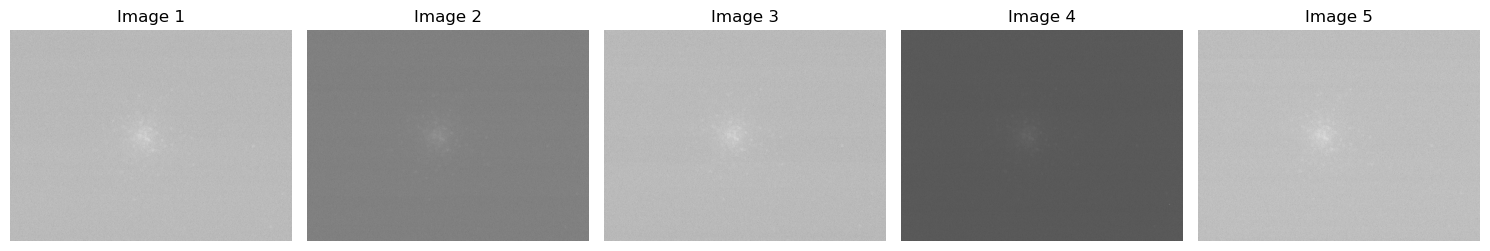

In [27]:
plt.figure(figsize=(15, 3))   # wide row of images

for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(images[i], origin="lower", cmap="gray")
    plt.title(f"Image {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
vmin = min(np.min(img) for img in images)
vmax = max(np.max(img) for img in images)

plt.figure(figsize=(15, 3))

for i in range(5):
    plt.subplot(1, 5, i+1)
    im = plt.imshow(images[i], origin="lower", cmap="gray", vmin=vmin, vmax=vmax)
    plt.title(f"Image {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.colorbar(im, ax=plt.gcf().get_axes(), location='right')
plt.show()

In [ ]:
combined_image = np.median(np.stack(images, axis=0), axis=0)

median_pixel = np.median(combined_image)
print("Median pixel value of combined image:", median_pixel)

plt.figure(figsize=(6,4))
plt.hist(combined_image.ravel(), bins=50)
plt.xlabel("Pixel value")
plt.ylabel("Count")
plt.title("Histogram of combined image")
plt.show()

vmin = np.percentile(combined_image, 5)
vmax = np.percentile(combined_image, 95)
print("vmin:", vmin, "vmax:", vmax, "difference:", vmax - vmin)

plt.figure(figsize=(4,4))
plt.imshow(combined_image, origin="lower", vmin=vmin, vmax=vmax, cmap="gray")
plt.colorbar(label="Pixel value")
plt.title("Combined (median) image")
plt.show()

# step 5
fits.writeto("combined.fits", combined_image, overwrite=True)
print("Saved combined image to combined.fits")